In [8]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
# ML library
from sklearn import model_selection
from sklearn import metrics
# Data Balancing Library
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
# regression-multiple-methods.ipynb
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA

### Loading Data and Data Summary

In [2]:
metric_table = pd.DataFrame()
# Algorithms

algorithms = {
    'Logistic-Regression': LogisticRegression(multi_class='ovr',random_state=42, max_iter=2000),
    # 'SVC-Linear': SVC(kernel='linear', probability=True,random_state=42),
    # 'SVC-RBF': SVC(kernel='rbf', probability=True,random_state=42),
    # 'RandomForest': RandomForestClassifier(random_state=42),
    # 'Neural-Network-5': MLPClassifier(hidden_layer_sizes=[5], max_iter=20000),
}
file_path = 'patient-data.csv'
np.random.seed(42)
# load the dataset


In [ ]:
def trainAndTestWithSampling(X, y, model, model_name):
  np.random.seed(5)
  # split into train/test sets with same class ratio
  trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42)

  # fit model
  model.fit(trainX, trainy)
  # predict on test set
  y_pred = model.predict(testX)
  # evaluate predictions
  # Accuracy
  print("Accuracy:", accuracy_score(testy, y_pred))
  print('\nConfusion Metrics\n', confusion_matrix(testy, y_pred))
  print("\nClassification Report:\n", classification_report(testy, y_pred))
  return trainX, testX, trainy, testy

In [4]:
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    # calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(len(dataframe.columns))]
    return vif_data

In [ ]:
# 2. Iterative VIF Reduction Loop
vif_threshold = 5.0 # Set your desired threshold

def progressive_vif_analysis(X_current, X_test_current, trainy, testy, algorithm, model_name):
    dropped_features = []
    metrics_history = pd.DataFrame()
    while True:
        vif_results = calculate_vif(X_current)
        # Exclude the intercept from VIF check for dropping features
        highest_vif_feature = vif_results[vif_results['feature'] != 'intercept'].sort_values(by='VIF', ascending=False).iloc[0]
        
        if highest_vif_feature['VIF'] > vif_threshold:
            feature_to_drop = highest_vif_feature['feature']
            dropped_features.append(feature_to_drop)
            print(f"Dropping '{feature_to_drop}' (VIF: {highest_vif_feature['VIF']:.2f})")
            # Drop the feature from both train and test sets
            X_current = X_current.drop(columns=feature_to_drop)
            X_test_current = X_test_current.drop(columns=feature_to_drop)
            # Train model and record metrics *after* the drop
            trainAndTestWithSampling(X_current, trainy, algorithm, model_name)
            # metrics_history.at[feature_to_drop, 'R-squared Train'] = r2_train
            # metrics_history.at[feature_to_drop, 'RMSE Train'] = rmse_train
            # metrics_history.at[feature_to_drop, 'R-squared Test'] = r2_test
            # metrics_history.at[feature_to_drop, 'RMSE Test'] = rmse_test
        else:
            print(f"\nAll remaining features have VIF below threshold of {vif_threshold}.")
            break   
    print("------------------- progressive_vif_analysis ------------------------------")     
    print(f'ALGORITHM {model_name}')
    print(f'Total dropped features are {dropped_features} ')   
    # print(f'Metrics History\n {metrics_history.to_string()}')  
    print("------------------- progressive_vif_analysis ------------------------------")           

## VIF Program Starting Here!

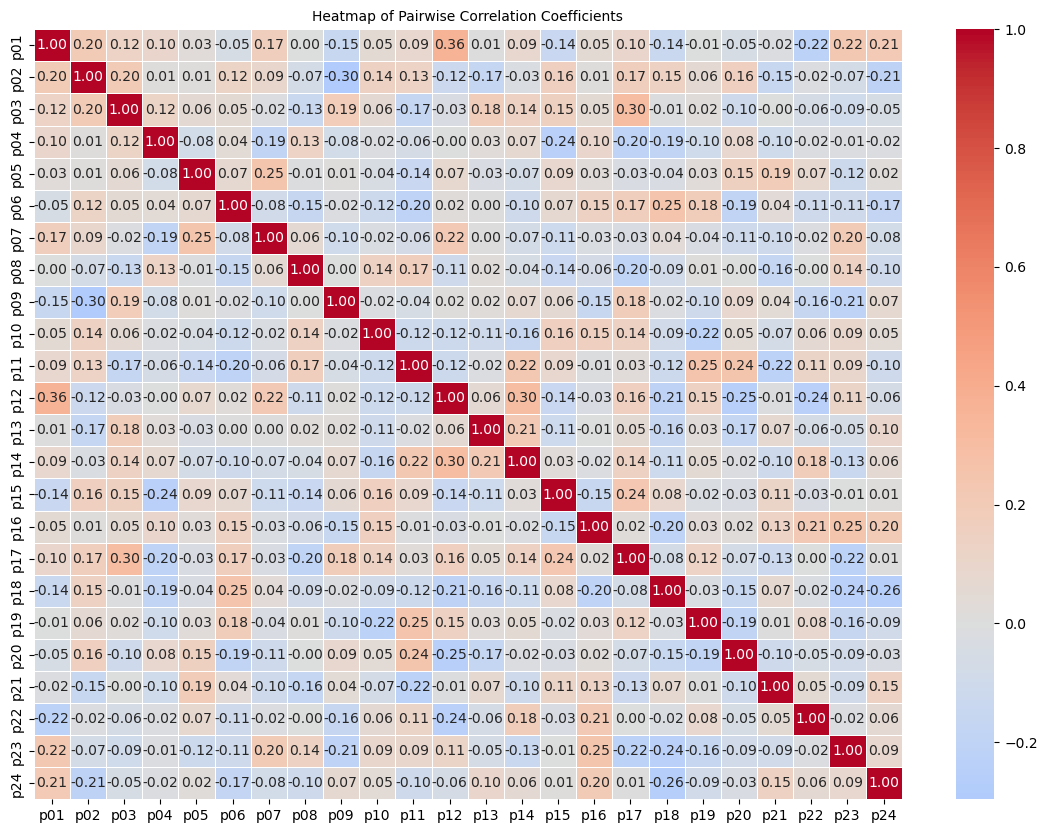

      feature          VIF
24  intercept  4027.034345
11        p12     2.299446
10        p11     1.907769
0         p01     1.799608
22        p23     1.729707
13        p14     1.684065
16        p17     1.680897
1         p02     1.667641
2         p03     1.653373
19        p20     1.638037
17        p18     1.621779
14        p15     1.577016
23        p24     1.557834
5         p06     1.543273
21        p22     1.520067
15        p16     1.510346
8         p09     1.489717
18        p19     1.488828
3         p04     1.403534
4         p05     1.402101
6         p07     1.397119
9         p10     1.394865
20        p21     1.345991
7         p08     1.311563
12        p13     1.279144
--------------------------------------------------


c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7763713080168776

Confusion Metrics
 [[111   0  16   0   0   0]
 [  7  72  17   0   8   0]
 [ 19   7  89   0   5   0]
 [  0   3   2   0   0   0]
 [  0  18   4   0  75   0]
 [  0   0   0   0   0  21]]

Classification Report:
                precision    recall  f1-score   support

       Anemia       0.81      0.87      0.84       127
     Diabetes       0.72      0.69      0.71       104
      Healthy       0.70      0.74      0.72       120
Heart Disease       0.00      0.00      0.00         5
     Thalasse       0.85      0.77      0.81        97
     Thromboc       1.00      1.00      1.00        21

     accuracy                           0.78       474
    macro avg       0.68      0.68      0.68       474
 weighted avg       0.77      0.78      0.77       474



c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Logistic-Regression
Total dropped features are [] 
------------------- progressive_vif_analysis ------------------------------
Empty DataFrame
Columns: []
Index: []
-------------------------------------------------


In [7]:
df = pd.read_csv(file_path)
df_clean = df.dropna()
X = df_clean.drop(columns=['Ailment'])
# Note: VIF analysis requires a constant/intercept term to be included
X['intercept'] = 1
y = df_clean['Ailment']
# b. Heatmap
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap of Pairwise Correlation Coefficients', fontsize=10)
plt.show()

# Run the function
vif_results = calculate_vif(X)
# Display results, sorting by VIF value for easier observation
print(vif_results.sort_values(by='VIF', ascending=False))
print('-'*50)
for model_name, algorithm in algorithms.items():
    trainX, testX, trainy, testy = trainAndTestWithSampling(X,y,False,False,algorithm, model_name)

    # Work on a copy of the training data
    X_current = trainX.copy()
    X_test_current = testX.copy()
    progressive_vif_analysis(X_current, X_test_current, trainy, testy, algorithm, model_name)

# Display the metrics' Tables
print(metric_table.to_string())
print("-------------------------------------------------")


## PCA Program Starting Here!

In [9]:

def train_and_evaluate_with_pca(X,y,n_pcs_list):
    # Ensure X only contains the features you want to analyze with PCA

    # --- PCA Process ---
    pca_results = pd.DataFrame(columns=['Model', 'Features', 'classification_report'])
    # Step 1: Standardize the data
    # PCA is affected by scale, so standardization (mean=0, variance=1) is crucial.
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 2: Perform PCA
    # We use all components initially to analyze total variance contribution
    pca = PCA(n_components=None) # None keeps all original dimensions as PCs
    pca.fit(X_scaled)

    # Step 3: Extract explained variance ratios
    # The explained_variance_ratio_ attribute provides the percentage of variance 
    # explained by each individual principal component.
    explained_variance = pca.explained_variance_ratio_

    # --- Plotting the Contributions (Bar Chart) ---
    plt.figure(figsize=(10, 6))
    # Create labels for the X-axis (PC1, PC2, PC3, ...)
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]

    # Plotting the bar chart
    plt.bar(pc_labels, explained_variance * 100, color='skyblue', edgecolor='black')
    # Adding labels and title
    plt.xlabel('Principal Component')
    plt.ylabel('Percentage of Explained Variance (%)')
    plt.title('Contribution of Each Principal Component to Total Variance')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--')

    for n_pcs in n_pcs_list:
        pca_n = PCA()
        X_pca = pca_n.fit_transform(X_scaled)
        X_pca_subset = X_pca[:, :n_pcs]  # Select the first `n_pcs` PCs
        print(f"\nUsing top {n_pcs} principal components:")
        print(f"Original dimensions: {X_scaled.shape[1]}")
        print(f"Reduced dimensions: {X_pca_subset.shape[1]}")
        np.random.seed(5)
        # split into train/test sets with same class ratio
        trainX, testX, trainy, testy = model_selection.train_test_split(X_pca_subset, y, test_size=0.2,random_state=42)

        for model_name, model in algorithms.items():
            # Train the model
            model.fit(trainX, trainy)
            y_pred = model.predict(testX)
            # evaluate predictions
            # Accuracy
            print("Accuracy:", accuracy_score(testy, y_pred))
            print('\nConfusion Metrics\n', confusion_matrix(testy, y_pred))
            print("\nClassification Report:\n", classification_report(testy, y_pred))
            # Store results
            pca_results.loc[len(pca_results)] = {
                'Model': model_name,
                'Features': f'{n_pcs} PCs',
                'classification_report': classification_report(testy, y_pred)
            }
     # Train and evaluate models using original features
    trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
    for model_name, model in algorithms.items():
        model.fit(trainX, trainy)

        y_pred = model.predict(testX)
            # evaluate predictions
            # Accuracy
        print("Accuracy:", accuracy_score(testy, y_pred))
        print('\nConfusion Metrics\n', confusion_matrix(testy, y_pred))
        print("\nClassification Report:\n", classification_report(testy, y_pred))

        # Store results
        pca_results.loc[len(pca_results)] = {
                'Model': model_name,
                'Features': f'{n_pcs} PCs',
                'classification_report': classification_report(testy, y_pred)
            }
    return pca_results
    

C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_31296\2964990445.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Ailment_code'] = le.fit_transform(df_clean['Ailment'])
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Using top 3 principal components:
Original dimensions: 24
Reduced dimensions: 3
Accuracy: 0.36075949367088606

Confusion Metrics
 [[94 20  6  0  7  0]
 [22 44 29  0  9  0]
 [47 53 11  0  9  0]
 [ 1  0  2  0  2  0]
 [44 20 11  0 22  0]
 [ 8  5  8  0  0  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.74      0.55       127
           1       0.31      0.42      0.36       104
           2       0.16      0.09      0.12       120
           3       0.00      0.00      0.00         5
           4       0.45      0.23      0.30        97
           5       0.00      0.00      0.00        21

    accuracy                           0.36       474
   macro avg       0.23      0.25      0.22       474
weighted avg       0.32      0.36      0.32       474


Using top 5 principal components:
Original dimensions: 24
Reduced dimensions: 5
Accuracy: 0.41561181434599154

Confusion Metrics
 [[86 13 14  0 14  0]
 [13 51 23  0 17  0]
 

c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\sit

Accuracy: 0.7109704641350211

Confusion Metrics
 [[115   0  12   0   0   0]
 [  0  76  15   0  13   0]
 [  7  18  71   0  24   0]
 [  1   1   2   0   1   0]
 [ 21   0  14   0  62   0]
 [  0   8   0   0   0  13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       127
           1       0.74      0.73      0.73       104
           2       0.62      0.59      0.61       120
           3       0.00      0.00      0.00         5
           4       0.62      0.64      0.63        97
           5       1.00      0.62      0.76        21

    accuracy                           0.71       474
   macro avg       0.63      0.58      0.60       474
weighted avg       0.70      0.71      0.70       474


Using top 15 principal components:
Original dimensions: 24
Reduced dimensions: 15
Accuracy: 0.7932489451476793

Confusion Metrics
 [[121   0   6   0   0   0]
 [  9  81   6   0   8   0]
 [ 17  10  87   0   6   0]
 [  1  

c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\sit

Accuracy: 0.770042194092827

Confusion Metrics
 [[111   0  16   0   0   0]
 [  7  63  17   0  17   0]
 [ 15  10  95   0   0   0]
 [  0   3   2   0   0   0]
 [  0  18   4   0  75   0]
 [  0   0   0   0   0  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       127
           1       0.67      0.61      0.64       104
           2       0.71      0.79      0.75       120
           3       0.00      0.00      0.00         5
           4       0.82      0.77      0.79        97
           5       1.00      1.00      1.00        21

    accuracy                           0.77       474
   macro avg       0.67      0.67      0.67       474
weighted avg       0.76      0.77      0.76       474

                 Model Features  \
0  Logistic-Regression    3 PCs   
1  Logistic-Regression    5 PCs   
2  Logistic-Regression   10 PCs   
3  Logistic-Regression   15 PCs   
4  Logistic-Regression   15 PCs   

          

c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SUSHANT\anaconda3\Lib\sit

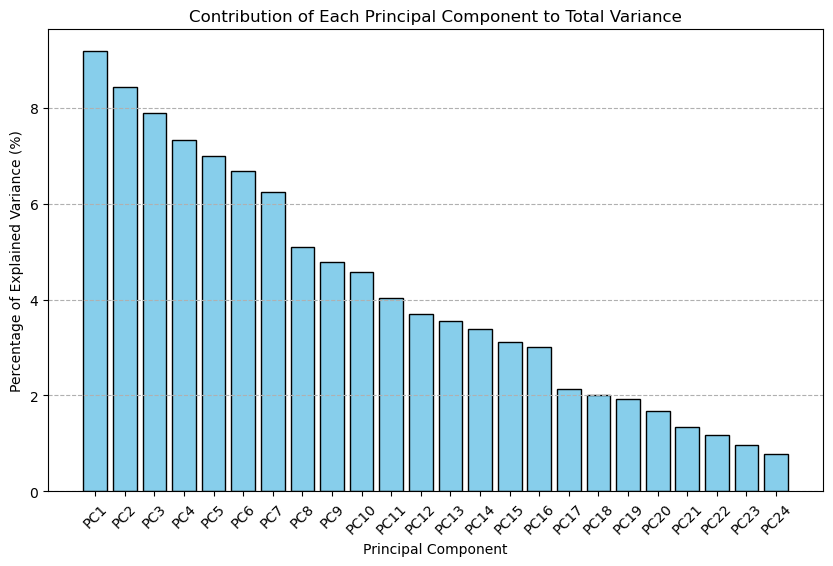

In [12]:
n_pcs_list = [3, 5, 10, 15]
df = pd.read_csv(file_path)
df_clean = df.dropna()
X = df_clean.drop(columns=['Ailment'])
le = LabelEncoder()
df_clean['Ailment_code'] = le.fit_transform(df_clean['Ailment'])
y = df_clean['Ailment_code'] 
pca_results = train_and_evaluate_with_pca(X,y, n_pcs_list)
# Display results
print(pca_results)
print("----------------------------------------------------------------\n\n")